<a href="https://colab.research.google.com/github/ldfha/RotemAI/blob/main/projects/pro15rl/rl7minicar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# 강화학습으로 미니카 학습 모델 생성 + 애니메이션 <= DQN
# MiniCar : (x, y, theta, v)의 상태를 가짐. action은 3가지(좌회전, 직진, 우회전)
# 보상은 중앙에서 멀어질수록 불이익, 목표 도착시 보상 +10, 도로 이탈 시 보상 -10
# 현재 정책 학습은 main-model이 담당, 안정적인 목표값 제공은 target-model이 담당
# 메모리 버퍼에 경험을 저장
!pip install gymnasium

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib import animation
from tensorflow import keras
from collections import deque
import random
import gymnasium as gym
from gymnasium import spaces

In [9]:
# 사용자 정의 환경
class MiniCarEnv(gym.Env):
  def __init__(self) -> None:
    super(MiniCarEnv, self).__init__()

    # 상태공간 [x좌표, y좌표, 방향각, 속도]
    self.observation_space = spaces.Box(
      low = np.array([0, 0, -np.pi, 0], dtype=np.float32),
      high = np.array([100, 100, np.pi, 5], dtype=np.float32)
    )

    # 행동공간 [0:좌회전, 1:직진, 2:우회전]
    self.action_space = spaces.Discrete(3)
    self.reset()

  def reset(self, seed=None, options=None):
    x=10.0
    y = 50.0
    theta = 0.0
    v = 1.0
    self.state = np.array([x, y, theta, v])
    return self.state, {}

  def step(self, action):
    x, y, theta, v = self.state.astype(np.float32)

    # 조향 갱신
    steer_step = 0.1
    if action == 0:   # 좌회전
      theta -= steer_step
    elif action == 2: # 우회전
      theta += steer_step

    theta *= 0.98 # 조향 감쇠(자연스럽게 직진으로 돌아옴)
    # 각도 wrapping : 각도를 항상 [-π, +π] 범위 안에 맞추기 - 각도 정규화
    theta = (theta + np.pi) % (2 * np.pi) - np.pi

    # 이동
    # 2차원 좌표상에서
    # x축 이동량 : x = x + v * cos(theta)
    # y축 이동량 : y = y + v * sin(theta)
    n = np.random.normal(0, 0.2, size=2)  # 강화학습에 반영할 노이즈(센서오차, 바람, 미끄러짐...)
    x_prev = x
    x += v * np.cos(theta) + n[0]
    y += v * np.sin(theta) + n[1]

    self.state = np.array([x, y, theta, v], dtype=np.float32)

    # 보상 설계 - 중앙선에서 벗어날 경우 벌점 고려
    center_penalty = --0.05 * abs(y - 50.0)
    # 진행 보상 : 직진 한 만큼 보상 (뒤로/옆 억제)
    process = max(0.0, x - x_prev)  * 0.8
    # 생존 보상 - 너무 크지 않게
    alive = 0.2

    reward = alive + center_penalty + process

    # 종료 조건
    terminated = False
    truncated = False

    if x > 90 and 0 <= y <= 10:
      reward += 50.0
      terminated = True
    elif not(0 <= x <= 100 and 0 <= y <= 100):
      reward -= 15.0
      terminated = True

    return self.state, float(reward), terminated, truncated, {}


In [12]:
# DQN 모델 생성
def create_dqn(input_dim, output_dim):
    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim, )),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(output_dim, activation='linear')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse')
    return model

# 실험 설정
episodes = 100
runs = 1   # 전체 학습을 몇 번 반복할 지 설정  2 ~ 3 을 권장

all_run_rewards = []    # 에피소드별 총 보상 저장
all_run_deviations = [] # 도로 중앙(y=50)으로 부터 평균 편차 저장
final_trajectories = [] # 에피소드별 이동 경로를 저장

# 학습 - 강화학습의 특성(무작위)상 여러번 실행해 평균 성능을 확인하길 권장
for run in range(runs):
    env = MiniCarEnv()
    state_dim = int(env.observation_space.shape[0])   # 관측 차원 수 : 4
    num_actions = int(env.action_space.n)     # 가능한 행동 수 : 3
    model = create_dqn(state_dim, num_actions)   # main model (Main Network)
    target_model = create_dqn(state_dim, num_actions)   # target model (Target Network)
    target_model.set_weights(model.get_weights())
    # model : 현재 Q값을 예측하고 학습하는 신경망
    # target_model : 비교 기준이 되는 고정된 Q값을 제공(학습 목표값 계산에 사용)

    # 하이퍼 파라미터 설정
    gamma = 0.99
    epsilon = 0.6
    epsilon_decay = 0.997
    epsilon_min = 0.02

    batch_size = 32   # 경험을 32개씩 샘플링해서 학습
    memory = deque(maxlen=2000)  # ReplayBuffer 크기

    reward_history = []  # 에피소드 마다 받은 총보상을 저장
    deviation_history = [] # 주행 중 y값이 도로중심에서 얼마나 벗어났는지 평균펀차 저장
    run_trajectories = []

    CENTER_Y = 50.0

    for ep in range(episodes):
        state, _ = env.reset()
        print(f'Run {run} 에피소드 시작 : ep = {ep}, 초기 상태={state}')

        total_reward = 0
        trajectory = []
        done = False

        for step in range(200):
            state_input = np.reshape(state, [1, state_dim])  # 1차원 -> 2차원

            # 탐험, 이용 결정
            if np.random.rand() < epsilon:
                action = np.random.choice(num_actions)
            else:
                q_values = model.predict(state_input, verbose=0)
                action = np.argmax(q_values[0])

            next_state, reward, done, _, _ = env.step(action)
            memory.append((state, action, reward, next_state, done))

            # 경로 및 보상 누적
            trajectory.append(state)
            total_reward += reward
            state = next_state
            if done: break

        # 하나의 메피소드가 끝난 뒤, 그 동안의 성과(보상, 이동경로, 편차 등)를 기록
        reward_history.append(total_reward)
        traj = np.array(trajectory)   # 이동경로 배열로 변환 (벡터 연산 가능)
        mean_deviation = np.mean(np.abs(traj[:, 1] - CENTER_Y))  # 평규 편차 계산

        deviation_history.append(mean_deviation)
        run_trajectories.append((ep, trajectory.copy())) # 이동 경로 저장
        print(f'Run {run} 에피소드 종료 : ep={ep}, \
              총보상=[total_reward:.2f], 편차={mean_deviation:.2f}, 종료상태={state}')

        # 메모리에서 무작위 샘플링 후 Q-netwok 갱신
        if len(memory) >= batch_size:
            minibatch = random.sample(memory, batch_size)

            states, targets = [], []  # 학습에 사용할 입력(states)과 목표값(targets) 누적용

            # 각 샘플에 대해 Q값 계산
            for s, a, r, s_next, d in minibatch:
                s_input = np.reshape(s, [1, state_dim])
                s_next_input = np.reshape(s_next, [1, state_dim])

                target = model.predict(s_input, verbose=0)[0]  # 현재 상태s 에서 각 행동의 Q값을 예측

                if d:
                    target[a] = r   # 종료된 상태면 단순히 보상이 정답
                else:
                    t_next = target_model.predict(s_next_input, verbose=0)[0]  # target_model로 다음 상태의 Q값을 예측
                    target[a] = r + gamma * np.max(t_next)

                # 학습 입력/타겟 누적
                states.append(s)
                targets.append(target)

            # Q-Network 학습
            model.fit(np.array(states), np.array(targets), epochs=1, verbose=0)

        if epsilon > epsilon_min:
            epsilon *= epsilon_decay

        if ep % 10 == 0:   # target network 갱신
            target_model.set_weights(model.get_weights())

    # 하나의 run 안에서 각 에피소드별 보상
    all_run_rewards.append(reward_history)
    all_run_deviations.append(deviation_history)

    if run == runs - 1:   # 마지막 run의 경로 데이터 저장
        final_trajectories = run_trajectories

Run 0 에피소드 시작 : ep = 0, 초기 상태=[10. 50.  0.  1.]
Run 0 에피소드 종료 : ep=0,               총보상=[total_reward:.2f], 편차=4.70, 종료상태=[100.39399    59.28806     1.2221158   1.       ]
Run 0 에피소드 시작 : ep = 1, 초기 상태=[10. 50.  0.  1.]
Run 0 에피소드 종료 : ep=1,               총보상=[total_reward:.2f], 편차=15.69, 종료상태=[100.39658     36.987892     0.77305293   1.        ]
Run 0 에피소드 시작 : ep = 2, 초기 상태=[10. 50.  0.  1.]
Run 0 에피소드 종료 : ep=2,               총보상=[total_reward:.2f], 편차=16.68, 종료상태=[100.24422     41.529663     0.48376942   1.        ]
Run 0 에피소드 시작 : ep = 3, 초기 상태=[10. 50.  0.  1.]
Run 0 에피소드 종료 : ep=3,               총보상=[total_reward:.2f], 편차=13.33, 종료상태=[100.31775    27.390512    0.7454567   1.       ]
Run 0 에피소드 시작 : ep = 4, 초기 상태=[10. 50.  0.  1.]
Run 0 에피소드 종료 : ep=4,               총보상=[total_reward:.2f], 편차=24.49, 종료상태=[100.36977     32.12636      0.45346045   1.        ]
Run 0 에피소드 시작 : ep = 5, 초기 상태=[10. 50.  0.  1.]
Run 0 에피소드 종료 : ep=5,               총보상=[total_reward:.2f], 편차=23.26, 종료상태=[

Success rate: 32.0%


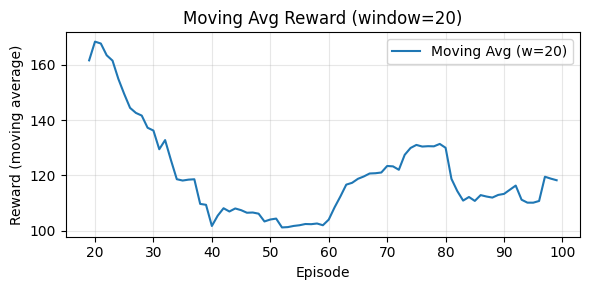

'\n이 그래프는 매우 만족스러운 학습 결과를 보여주는 전형적인 DQN 패턴이다.\n'

In [13]:
# 강화학습 : 미니카 실습 시각화 관련 코드 -------------------------------------------------------------

# “성공률” 체크하는 간단 지표 : 성공 여부는 "ep 끝에서 x>90"로 판정
# 이 그래프가 우상향하고, 성공률이 70%+로 올라가면 “안정”으로 봐도 좋다.
success_flags = [traj_end[0] > 90 for _, traj in run_trajectories for traj_end in [traj[-1]]]
success_rate = sum(success_flags) / len(success_flags)
print(f"Success rate: {success_rate*100:.1f}%")

# 이동 평균 보상(예: 20-ep window)
def moving_avg(a, w=20):
    return np.convolve(a, np.ones(w)/w, mode='valid')

w = 20
ma = moving_avg(reward_history, w)
episodes = np.arange(w-1, w-1 + len(ma))  # 에피소드 번호 정렬

plt.figure(figsize=(6,3))
plt.plot(episodes, ma, label=f"Moving Avg (w={w})")
plt.title("Moving Avg Reward (window=20)")
plt.xlabel("Episode")
plt.ylabel("Reward (moving average)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

"""
이 그래프는 매우 만족스러운 학습 결과를 보여주는 전형적인 DQN 패턴이다.
"""

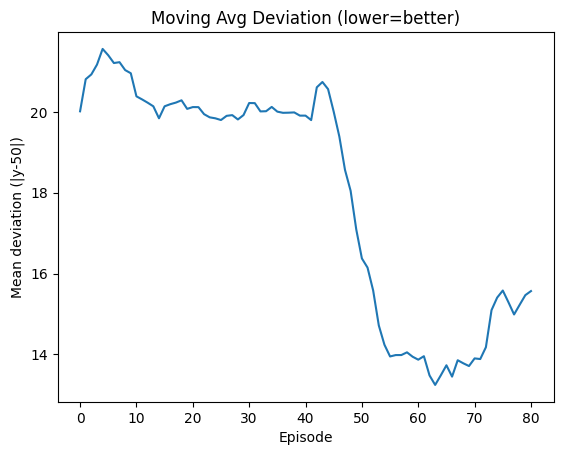

In [14]:
# 편차(Deviation) 이동평균 그래프 → 중앙선을 얼마나 잘 유지하는지 시각적으로 확인 가능.
plt.plot(moving_avg(deviation_history, 20))
plt.title("Moving Avg Deviation (lower=better)")
plt.xlabel("Episode")
plt.ylabel("Mean deviation (|y-50|)")
plt.show()

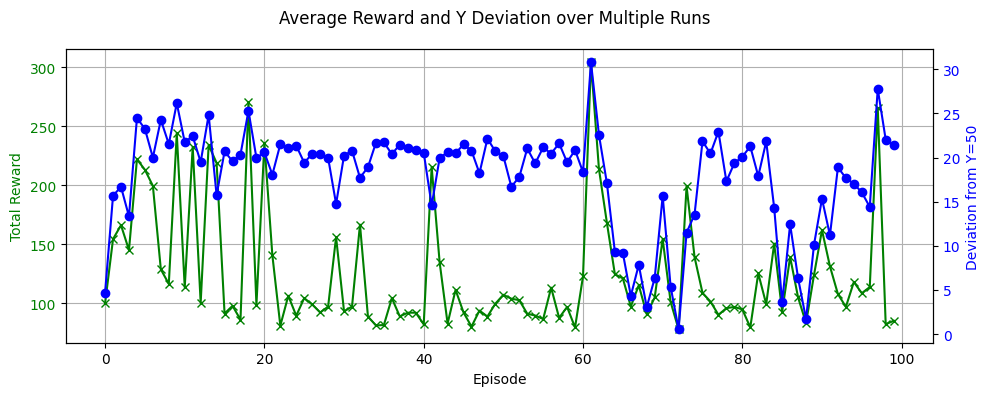

In [15]:
# 평균 시계열 분석 시각화
# 여러 번의 run을 평균낸 값을 기반으로, 에피소드마다의 보상 변화 추세를 시각화

# 평균 보상 / 평균 편차 계산
# all_run_rewards: 각 run의 reward 기록들 → 2차원 리스트
# (예: [[run0의 100개 보상], [run1의 100개 보상], ...])
mean_rewards = np.mean(all_run_rewards, axis=0)  # axis=0: 같은 에피소드끼리 평균을 냄
mean_deviations = np.mean(all_run_deviations, axis=0)

fig, ax1 = plt.subplots(figsize=(10, 4))
# ax1은 첫 번째 Y축을 가진 좌표축 객체
ax1.plot(mean_rewards, label="Average Total Reward", color='green', marker='x')
ax1.set_ylabel("Total Reward", color='green')
ax1.set_xlabel("Episode")
ax1.tick_params(axis='y', labelcolor='green')  # 왼쪽 Y축 눈금 글자도 초록색으로 맞춤
ax1.grid(True)

# 보상 그래프에 더해서, 도로 중심선(y=50)에서의 평균 편차도 함께 보여주는 이중 Y축 그래프
ax2 = ax1.twinx()   # ax1과 같은 X축을 공유하는 두 번째 Y축을 생성
# 왼쪽 Y축은 보상(total reward), 오른쪽 Y축은 중심선 편차(y deviation)

ax2.plot(mean_deviations, label="Average Y Deviation", color='blue', marker='o')
ax2.set_ylabel("Deviation from Y=50", color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
fig.suptitle("Average Reward and Y Deviation over Multiple Runs")  # 그래프 전체 제목
fig.tight_layout()
fig.savefig("aver_reward_devi.png")   # 이미지 파일로 저장


/tmp/ipykernel_33868/3262716040.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Blues", len(eps))  # "Blues"는 Matplotlib 지원 파란색 계열 그라데이션 컬러맵


'\n시각화 결과\n좌표: 도로는 0~100 정사각형, 시작점은 항상 (x≈10, y=50).\n회색 점선: x=50, y=50 기준선(세로는 중간 x, 가로는 중앙선 y=50).\n파란 점선들: 에피소드별 궤적. Ep>80만 표시했고, 에피소드가 뒤로 갈수록(번호 클수록) 더 진한 파란색이다.\n좌상단 “Step N”: 애니메이션의 현재 스텝.\n\n후반 에피소드일수록(진한 파랑) 중앙선 추종이 분명히 개선되어 있고, 남은 흔들림은 탐험·노이즈에 의한 자연스러운 변동으로 보인다.\n'

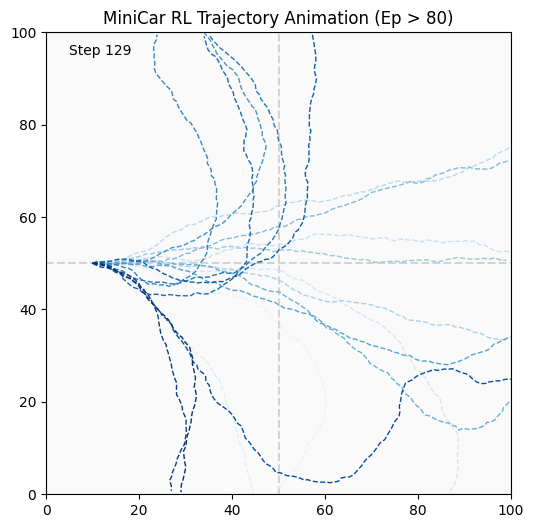

In [16]:
# 에피소드 단위로 시계열 분석 - 두 가지 지표를 동시에 시각화했다.
# 즉, 여러 번의 학습(Run)을 통해 얻은 평균 보상과 도로 중심선(Y=50)으로부터의 편차를 에피소드마다 시각화한 것.
# 1) 왼쪽 Y축 (녹색 선): Total Reward : 각 에피소드에서 얻은 총 보상의 평균.
#     보상 증가는 학습이 잘 되고 있음을 의미한다.
#     0 이상이면 좋은 성과, 0 이하면 도로 밖으로 벗어나는 등의 패널티가 많았음을 의미.
# 2) 오른쪽 Y축 (파란 선): Deviation from Y=50
#    도로의 중앙선(Y=50) 으로부터 얼마나 벗어났는지를 나타내는 편차.
#    이 값이 작을수록 → 차가 중심선을 잘 따라감 (좋음),  클수록 → 도로에서 많이 벗어남 (나쁨)
# 3) X축 (Episode) : 0부터 99까지 총 100개 에피소드 동안의 학습 경과를 보여줌



# 에피소드 번호가 80보다 큰 것만 골라서,각 에피소드마다 색을 다르게 지정해 애니메이션하기 준비
import matplotlib.cm as cm   # 컬러맵(color map) 모듈(색상 그라데이션, 여러 선 서로 다른 색 지정)

# 에피소드(ep) 번호가 80 이상인 궤적만 필터링. final_trajectories: 전체 에피소드의 주행 경로 목록
filtered = [(ep, traj) for ep, traj in final_trajectories if ep > 80]

# 리스트를 dict로 변환. 키: 에피소드 번호, 값: 그 에피소드의 주행 경로
filtered_traj_by_episode = {ep: traj for ep, traj in filtered}
# 애니메이션에서 순서를 유지하기 위해 에피소드 번호를 정렬
eps = sorted(filtered_traj_by_episode.keys())

# 에피소드마다 색 지정 (점점 파래지도록)
cmap = cm.get_cmap("Blues", len(eps))  # "Blues"는 Matplotlib 지원 파란색 계열 그라데이션 컬러맵
# get_cmap("Blues", N)은 총 N개의 다른 농도의 파란색을 만든다

colors = [cmap(i) for i in range(len(eps))]  # colors는 에피소드마다 다른 파란색을 할당한 리스트

# 애니메이션 플롯 설정
fig, ax = plt.subplots(figsize=(6, 6))     # ax: 실제 그래프가 그려지는 좌표축 객체 (axes)
ax.set_xlim(0, 100)             # 도로 크기와 일치하도록 X축, Y축 범위를 0~100으로 설정
ax.set_ylim(0, 100)             # 미니카가 주행하는 공간의 실제 위치와 일치시킴
ax.set_title("MiniCar RL Trajectory Animation (Ep > 80)")
ax.axvline(50, color='lightgray', linestyle='--')    # 도로 중심선 시각화
ax.axhline(50, color='lightgray', linestyle='--')

# 배경 영역 표시(도로 표현) (0,0)부터 (100,100)까지의 사각형 영역에 회색 배경 추가
ax.add_patch(Rectangle((0, 0), 100, 100, linewidth=1, edgecolor='gray', facecolor='#f0f0f0', alpha=0.3))
text = ax.text(5, 95, '', fontsize=10)    # 텍스트 객체 생성 (Step 표시용)

# 각 에피소드마다 선 객체 미리 생성
lines = []   # lines 리스트에 저장하여 에피소드별 궤적을 각각 담당
for color in colors:
    # ax.plot([], []) → 비어 있는 선 그래프 하나 생성 (초기 상태)
    line, = ax.plot([], [], linestyle='--', color=color, linewidth=1)
    lines.append(line)

# 초기화 함수 : FuncAnimation의 init_func에 사용
# 애니메이션 시작 시: 모든 선(line)을 비움, 텍스트도 초기화. 항상 비어 있는 상태로부터 시작
def init():
    for line in lines:
        line.set_data([], [])
    text.set_text('')
    return lines + [text]

# 업데이트 함수 - 프레임마다 궤적 그리는 함수
def update(frame):
    for idx, ep in enumerate(eps):              # 각 에피소드별로 궤적 업데이트
        traj = filtered_traj_by_episode[ep]    # 해당 에피소드의 궤적
        if frame < len(traj):
            path = np.array(traj[:frame+1])    # 현재 frame까지의 경로
            lines[idx].set_data(path[:, 0], path[:, 1])  # (x, y)
    text.set_text(f"Step {frame}")              # 현재 step 번호 표시
    return lines + [text]
# 주요 동작 : frame 값은 0부터 증가하며 애니메이션의 시간축 역할
# 각 에피소드에 대해 : 궤적이 frame보다 길면 해당 시점까지의 경로를 set_data()로 업데이트
# 선이 점점 길어지며 자동 주행 궤적이 그려지는 효과 발생
# 텍스트에 현재 step 표시

# 프레임 수 계산: 프레임 수는 가장 긴 궤적 길이
# filtered_traj_by_episode는 ep > 80인 에피소드들의 주행 궤적 딕셔너리
# 각각의 궤적(traj)은 (x, y, theta, v) 상태 리스트로 이루어진 경로
max_len = max(len(traj) for traj in filtered_traj_by_episode.values())
# 가장 긴 궤적의 길이를 계산하여 → 애니메이션의 전체 프레임 수로 사용
# 예: ep 85의 궤적 길이 = 100, ep 92의 궤적 길이 = 115, ep 97의 궤적 길이 = 123
# max_len = 123 → 애니메이션은 총 123프레임으로 구성

# 애니메이션 생성
ani = animation.FuncAnimation(fig, update, frames=max_len, init_func=init, interval=50, blit=True)
# update : 매 프레임마다 호출할 함수
# frames=max_len : 총 프레임 수 (0부터 max_len - 1까지 반복)
# init_func=init : 애니메이션 시작 전에 한 번만 호출될 초기화 함수
# interval=50 : 프레임 간 시간 간격 (50ms → 초당 약 20프레임 느낌)
# blit=True   : 효율적으로 화면 일부만 업데이트 (성능 향상)

# Colab에서 HTML5 비디오로 애니메이션 출력
from IPython.display import HTML
# HTML(ani.to_jshtml())     또는
HTML(ani.to_html5_video())  # 둘 중 아무거나 사용 가능.

ani.save("minicarani_blue.mp4", fps=10, dpi=150)
# fps=10 → 초당 10프레임, dpi=150 → 해상도 설정 (Dots Per Inch)


"""
시각화 결과
좌표: 도로는 0~100 정사각형, 시작점은 항상 (x≈10, y=50).
회색 점선: x=50, y=50 기준선(세로는 중간 x, 가로는 중앙선 y=50).
파란 점선들: 에피소드별 궤적. Ep>80만 표시했고, 에피소드가 뒤로 갈수록(번호 클수록) 더 진한 파란색이다.
좌상단 “Step N”: 애니메이션의 현재 스텝.

후반 에피소드일수록(진한 파랑) 중앙선 추종이 분명히 개선되어 있고, 남은 흔들림은 탐험·노이즈에 의한 자연스러운 변동으로 보인다.
"""

In [ ]:
# 참고 : 각도 wrapping
def wrap_angle(theta):
  return (theta + np.pi) % (2 * np.pi) - np.pi

angle = np.deg2rad(370)   # 10
angle = np.deg2rad(-190)  # 170
angle = np.deg2rad(120)   # 120
print(np.rad2deg(wrap_angle(angle)))